In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import interpolate



In [2]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

In [106]:
def gen_X(n: int = 10, a: int = -3, b: int = 3):
    return np.random.uniform(a, b, n)

def f(x: np.ndarray):
    return 2 - x + x * x


In [107]:
def gen_feats(X: np.ndarray, p: int) -> np.ndarray:
    X = X[:, None]
    Xs = []
    for p_ in range(p+1):
        Xs.append(np.power(X, p_))

    out = np.concatenate(Xs, axis=-1)

    return out

In [181]:
list_results = []
for p in range(7):
    list_y0, list_f0, list_f0_hat = [], [], []
    for _ in range(1000):
        # Create X, y
        Xtrain = gen_X(n = 10)
        ytrain = f(Xtrain) + np.random.normal(0, 0.4, Xtrain.shape[0])

        Xtest = np.array([0])
        ftest = f(Xtest)
        ytest = ftest + np.random.normal(0, 0.4, 1)

        # create OLS model
        Xtrain_p = gen_feats(Xtrain, p)
        ols = LinearRegression()
        ols.fit(Xtrain_p, ytrain)

        # Predict on test data point
        Xtest_p = gen_feats(Xtest, p)
        ypred_test = ols.predict(Xtest_p)

        list_y0.append(ytest.item())
        list_f0.append(ftest.item())
        list_f0_hat.append(ypred_test.item())

    df_p = pd.DataFrame({
        'y0': list_y0,
        'f0': list_f0,
        'f0_hat': list_f0_hat
    })

    # Calculate terms
    var = np.var(df_p['f0'] - df_p['f0_hat'])
    bias_sq = np.square(np.mean(df_p['f0'] - df_p['f0_hat']))
    irr = np.square(df_p['y0'] - df_p['f0']).mean()
    total = irr + bias_sq + var
    mse = np.square(df_p['y0'] - df_p['f0_hat']).mean()

    list_results.append({
        'degree': p,
        'irreducible': irr,
        'bias_sq': bias_sq,
        'variance': var,
        'total': total,
        'mse': mse
    })

df_result = pd.DataFrame.from_records(list_results)
df_result

,degree,irreducible,bias_sq,variance,total,mse
0,0,0.162355,8.697663e+00,0.989907,9.849924,9.795014
1,1,0.159016,7.323084e+00,1.064003,8.546103,8.479745
2,2,0.173098,9.408039e-08,0.044522,0.217620,0.215291
3,3,0.158681,1.025585e-04,0.059948,0.218732,0.219055
4,4,0.163378,6.118530e-04,0.267885,0.431874,0.443364
5,5,0.148795,2.203898e-05,0.647352,0.796169,0.787115
6,6,0.158964,3.197783e-06,1.915887,2.074854,2.044686


In [182]:
cols = ['irreducible', 'bias_sq', 'variance', 'total']
xplot = np.linspace(0, 5, 100)
data_plot = {'degree': xplot}

for col in cols:
    tck = interpolate.splrep(df_result['degree'], df_result[col], k=2)
    data_plot[col] = interpolate.splev(xplot, tck)

df_plot = pd.DataFrame(data_plot)

Text(0.5, 1.0, '4 terms as a function of polynomial degree')

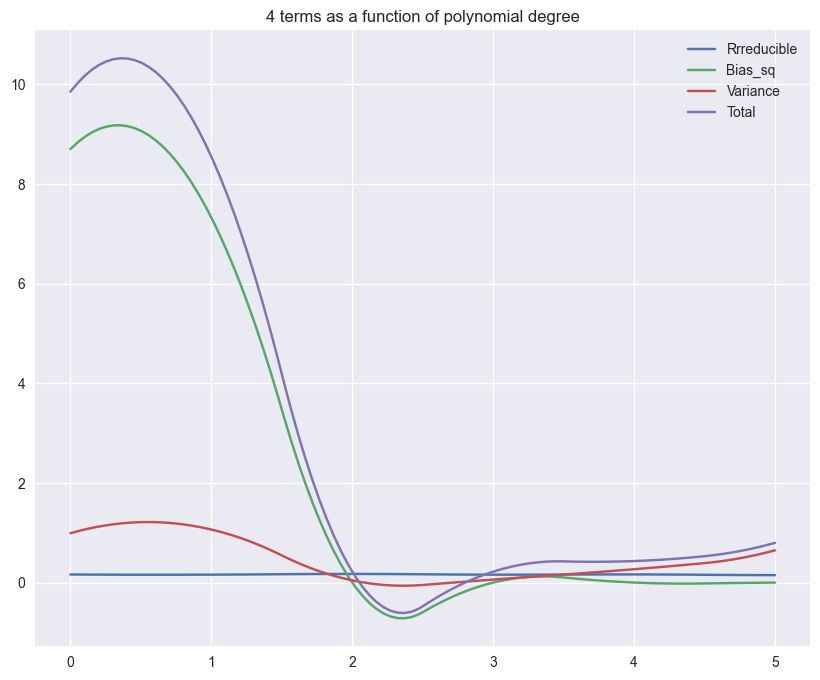

In [184]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111)

# ax.plot(df_result)

for col in cols:
    ax.plot(xplot, df_plot[col])
ax.legend(['Rrreducible', 'Bias_sq', 'Variance', 'Total'])
ax.set_title('4 terms as a function of polynomial degree')